In [1]:
import zipfile 
import pandas as pd
guardian_zip = zipfile.ZipFile('data/guardian_articles.zip')
guardian_df = pd.read_csv(guardian_zip.open('guardian_articles.csv'))

In [2]:
political_filtered_guardian_df = guardian_df[guardian_df['sectionName'] == 'Politics']
entertainment_filtered_guardian_df = guardian_df[guardian_df['sectionName'] == 'Entertainment']

In [3]:
male_terms = [
    "man", "men", "male", "boy", "he", "him", "his"
]

female_terms = [
    "woman", "women", "female", "girl", "she", "her", "hers"
]

In [8]:
!pip install regex
import re

def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

from collections import Counter

def count_gender_terms(article):
    tokens = tokenize(article)
    counts = Counter(tokens)
    
    male_count = sum(counts[word] for word in male_terms)
    female_count = sum(counts[word] for word in female_terms)
    
    return male_count, female_count


In [9]:
male_total = 0
female_total = 0
for i, article in enumerate(political_filtered_guardian_df['bodyContent']):
    male_count, female_count = count_gender_terms(article)
    male_total += male_count
    female_total += female_count

print(f"Total male mentions in Politics: {male_total}")
print(f"Total female mentions in Politics: {female_total}")

Total male mentions in Politics: 73969
Total female mentions in Politics: 31916


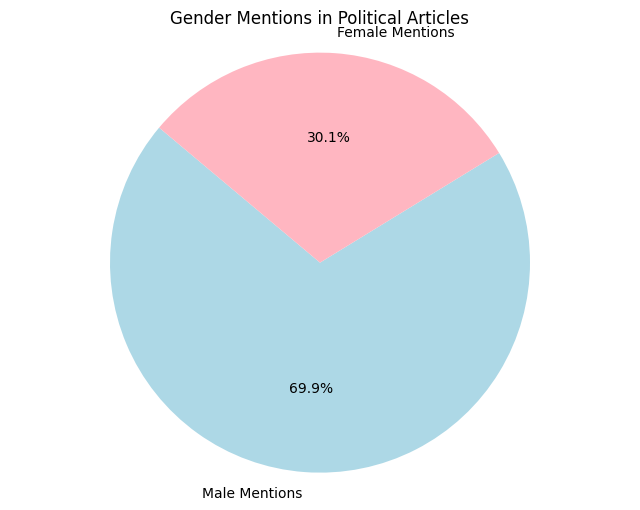

In [ ]:
import matplotlib.pyplot as plt
labels = ['Male Mentions', 'Female Mentions']
sizes = [male_total, female_total]
colors = ['lightblue', 'lightpink']
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Gendered Word Frequency in Guardian Political Articles')
plt.axis('equal')
plt.show()

In [12]:
import gender_guesser.detector as gender
detector = gender.Detector()
# example usage:
def absolute_gender(name):
    result = detector.get_gender(name)
    if result in ("male", "mostly_male"):
        return "male"
    elif result in ("female", "mostly_female"):
        return "female"
    else:
        return "unknown"


Labour’s unknown
Vote Leave’s unknown
Kurtz unknown
Willard” Jenkin unknown
Vote Leave unknown
Labour unknown
Dundee West unknown
De Piero unknown
Murnaghan unknown
Vote Leave unknown
Juncker unknown
Tusk’s Poland unknown
Cameron’s unknown
Amersham unknown
Pat McFadden unknown
Dr Martens unknown
Portcullis House unknown
Pat Jennings unknown
Labour unknown
MPs unknown
Twitter unknown
Twitter troll unknown
Hull unknown
Juncker unknown
Birmingham Yardley unknown
Britons unknown
Osborne unknown
Chuka Umunna unknown
Vote Leave unknown
Durham unknown
Hammersmith unknown
Feldman unknown
Osborne unknown
Labour unknown
Canary Wharf unknown
Capita unknown
Calais unknown
Chuka Umunna unknown
Dublin III unknown
Apple The unknown
Bermuda unknown
Downing St unknown
Lady Joanna Shields unknown
’s unknown
Labour unknown
Lib Dems unknown
Calais unknown
Sometimes Dave unknown
Cayman Islanders unknown
Better Jeff unknown
Sadiq Khan unknown
Zac Goldsmith unknown
patsy unknown
Lib Dems unknown
Holyrood unk

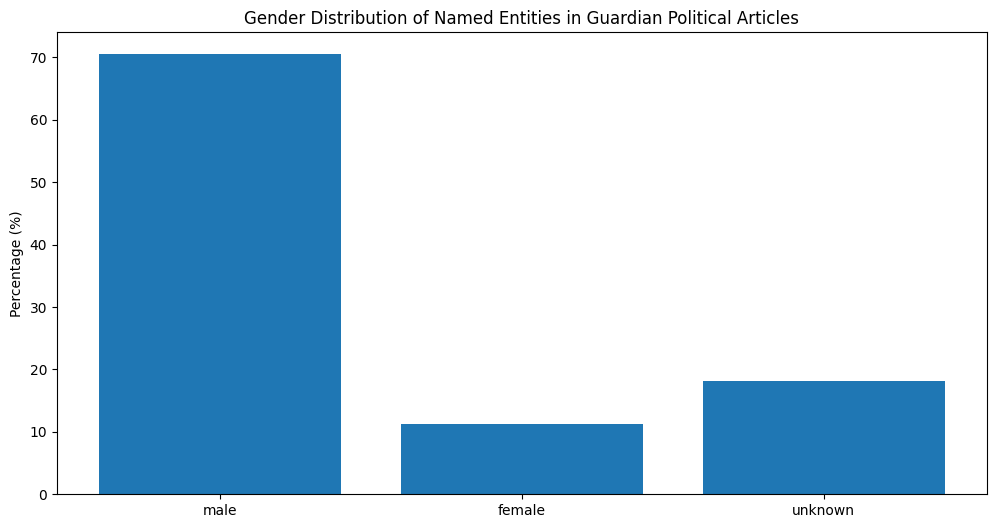

In [18]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
nlp = spacy.load("en_core_web_sm")
pd.set_option("display.max_rows", 200)

results = {'male': 0, 'female': 0, 'unknown': 0}

for i in range(min(100, 400)):
    content = str(political_filtered_guardian_df.head(i+1)['bodyContent'].values[-1])
    doc = nlp(content)
    prev_names = set()
    
    for ent in doc.ents:
        if ent.label_ == "PERSON":
            name = ent.text.strip()

            
            # Use first name for gender detection
            first_name = name.split()[0]
            second_name = name.split()[1] if len(name.split()) > 1 else ""
            result = absolute_gender(first_name)
            if name in prev_names or second_name in prev_names:
                continue
            prev_names.add(name)
            prev_names.add(second_name)
            results[result] += 1
            
            if result == "unknown":
                print(name, result)
total = sum(results.values())
for key in results:
    results[key] = results[key] / total * 100

plt.figure(figsize=(12, 6))
plt.bar(results.keys(), results.values())
plt.title('Gender Distribution of Named Entities in Guardian Political Articles')
plt.ylabel('Percentage (%)')
plt.show()
